# Data Analysis

In [1]:
library(dplyr)
library(car)
library(ggplot2)
library(rmarkdown)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode




In [2]:
dataset_url <- "https://raw.githubusercontent.com/wilkmzhou/STAT306_PROJECT_REPORT_2026/refs/heads/main/mercedes_benz_listings_cleaned.csv"

benzDataRaw <- read.csv(dataset_url)
head(benzDataRaw, n = 3)

,Vehicle_Name,Year,Vehicle_Age,Model_Series,Trim_Level,Body_Type,Is_AMG,Is_4MATIC,Mileage_Miles,Mileage_Category,Price_USD,Price_Category,Price_Per_Mile
,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<int>,<chr>,<dbl>
1,2025 Mercedes-Benz AMG S 63 E 4MATIC,2025,1,AMG S 63,S 63,Other,1,1,9860,Low (< 20K),151900,Luxury (> $70K),15.405680
2,2025 Mercedes-Benz GLE 580 4MATIC,2025,1,GLE,E 580,SUV,0,1,3154,Low (< 20K),82975,Luxury (> $70K),26.307863
3,2025 Mercedes-Benz GLS 450 4MATIC,2025,1,GLS,S 450,SUV,0,1,15496,Low (< 20K),75500,Luxury (> $70K),4.872225


In [3]:
benzData <- benzDataRaw |> 
    na.omit() |>                                                                                              # remove any NA rows 
    select(-Price_Per_Mile, -Price_Category, -Year, -Mileage_Category, -Vehicle_Name, -Model_Series, -Is_AMG) # remove redundant variables
head(benzData, n = 3)

,Vehicle_Age,Trim_Level,Body_Type,Is_4MATIC,Mileage_Miles,Price_USD
,<int>,<chr>,<chr>,<int>,<int>,<int>
1,1,S 63,Other,1,9860,151900
2,1,E 580,SUV,1,3154,82975
3,1,S 450,SUV,1,15496,75500


## Exploratory Data Analysis
### Numerical Variables

,Vehicle_Age,Mileage_Miles,Price_USD
Vehicle_Age,1.0000000,0.7895362,-0.5172287
Mileage_Miles,0.7895362,1.0000000,-0.5478500
Price_USD,-0.5172287,-0.5478500,1.0000000


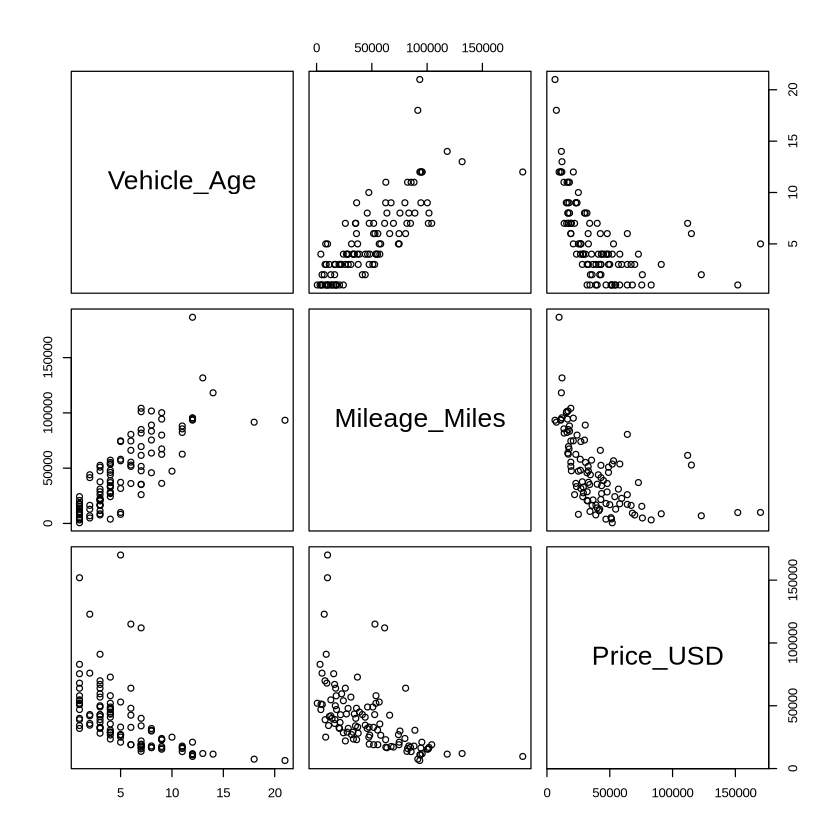

In [4]:
benzDataInt <- benzData |>
    select(-Trim_Level, -Body_Type, -Is_4MATIC) # filter dataset from categorical variables

pairs(benzDataInt) # scatterplot between each pair of numerical variables
cor(benzDataInt) # correlation between each pair of numerical variables

### Categorical Variables

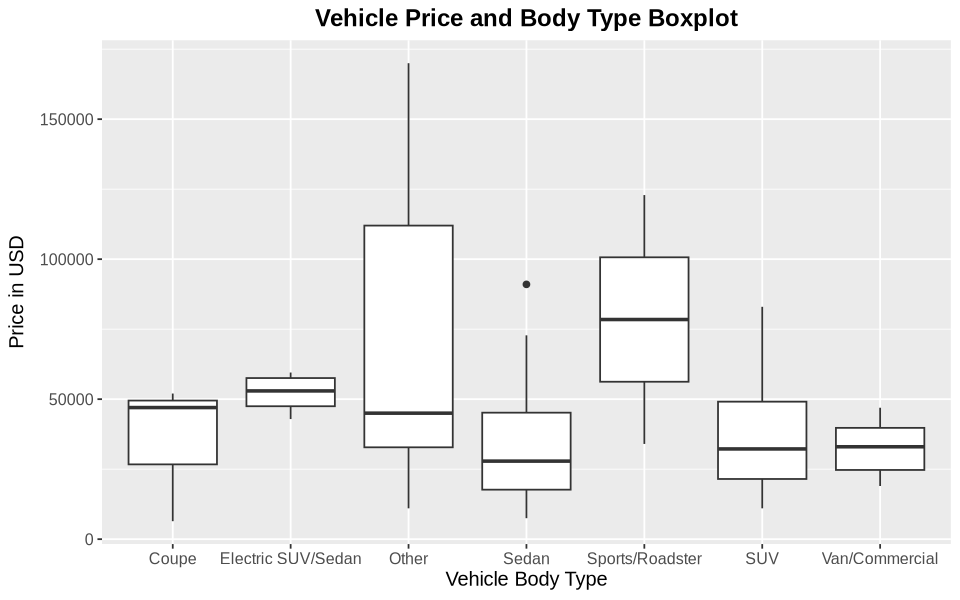

In [5]:
options(repr.plot.width = 8, repr.plot.height = 5)
benzDataCat <- benzData |>
    select(-Vehicle_Age, -Mileage_Miles) # filter dataset from numerical variables

benzBodyBoxplot <- benzDataCat |>
    ggplot(aes(x = Body_Type, y = Price_USD)) + 
    geom_boxplot() + 
    ylab("Price in USD") + # y-axis label change 
    xlab("Vehicle Body Type") + # x-axis label change
    ggtitle("Vehicle Price and Body Type Boxplot") + # title
    theme(plot.title = element_text(hjust = 0.5, face = "bold"), text = element_text(size = 12)) # title alignment and text size increase

benzBodyBoxplot

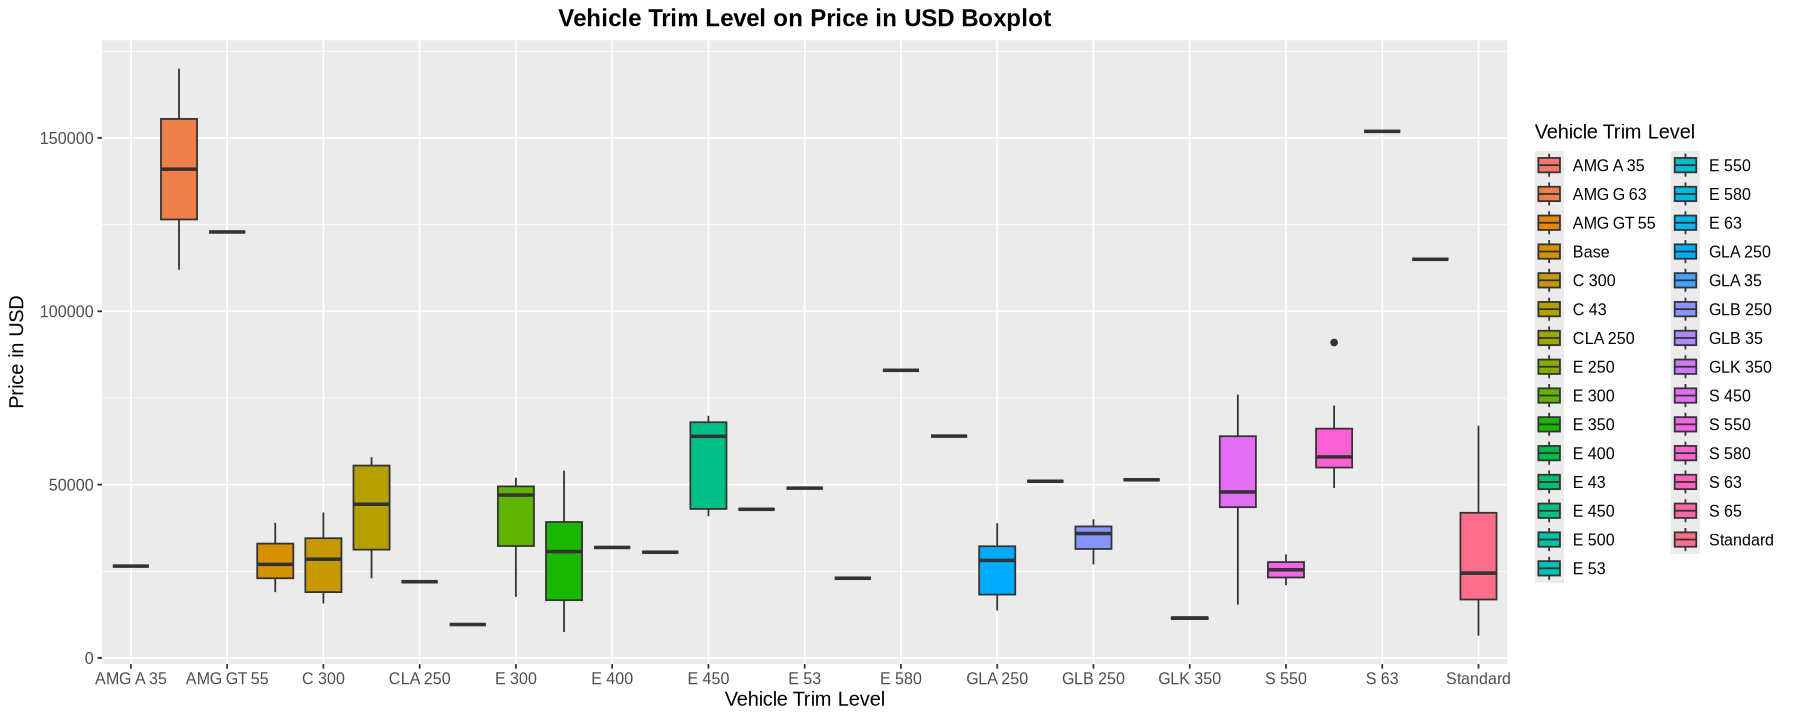

In [6]:
options(repr.plot.height = 6, repr.plot.width = 15)
benzDataCat$Trim_Level <- factor(benzDataCat$Trim_Level)
benzTrimBoxplot <- benzDataCat |>
    ggplot(aes(x = Trim_Level, y = Price_USD, fill = Trim_Level)) +
    geom_boxplot() +
    labs(x = "Vehicle Trim Level", y = "Price in USD", fill = "Vehicle Trim Level") + # label change
    ggtitle("Vehicle Trim Level on Price in USD Boxplot") + # add title 
    theme(plot.title = element_text(hjust = 0.5, face = "bold"), text = element_text(size = 12)) + # adjustments to title and text size
    scale_x_discrete(breaks = levels(benzDataCat$Trim_Level)[seq(1, 29, by = 2)]) # show x-axis indices every two categories
benzTrimBoxplot

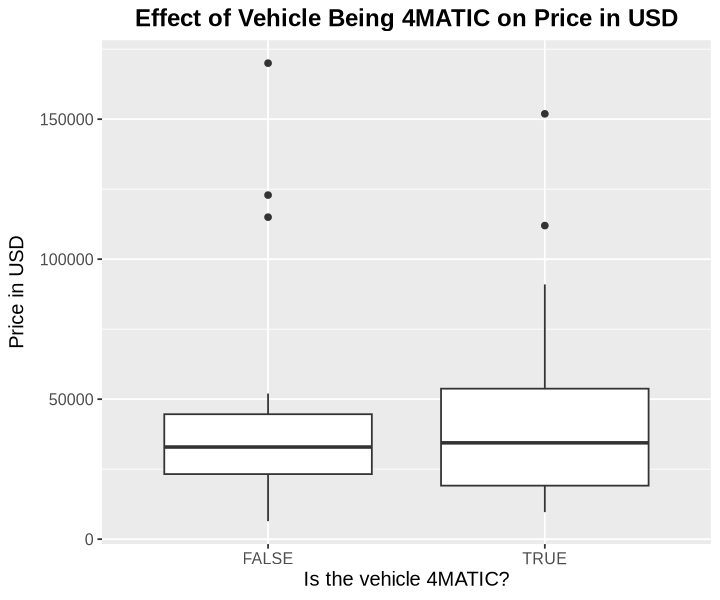

In [7]:
options(repr.plot.width = 6, repr.plot.height = 5)

benzDataCat$Is_4MATIC <- if_else(benzDataCat$Is_4MATIC == 1, TRUE, FALSE) 

benz4MATICBoxplot <- benzDataCat |>
    ggplot(aes(x = Is_4MATIC, y = Price_USD)) +
    geom_boxplot() + 
    labs(x = "Is the vehicle 4MATIC?", y = "Price in USD") +
    ggtitle("Effect of Vehicle Being 4MATIC on Price in USD") + 
    theme(plot.title = element_text(hjust = 0.5, face = "bold"), text = element_text(size = 12))  # adjustments to title and text size

benz4MATICBoxplot

### Fitting Linear Regression Model

In [8]:
benzFit1 <- lm(Price_USD ~ ., data = benzData) # fit linear regression model with all variables in filtered dataset

summary(benzFit1) # print linear regression fit statistics


Call:
lm(formula = Price_USD ~ ., data = benzData)

Residuals:
   Min     1Q Median     3Q    Max 
-20209  -2573      0   2358  20791 

Coefficients:
                              Estimate Std. Error t value Pr(>|t|)    
(Intercept)                  6.515e+04  1.255e+04   5.193 1.94e-06 ***
Vehicle_Age                 -1.595e+03  4.727e+02  -3.375  0.00121 ** 
Trim_LevelAMG G 63           1.087e+05  1.003e+04  10.829  < 2e-16 ***
Trim_LevelAMG GT 55          7.463e+04  1.572e+04   4.747 1.06e-05 ***
Trim_LevelBase              -5.061e+03  1.193e+04  -0.424  0.67282    
Trim_LevelC 300             -9.789e+03  9.774e+03  -1.002  0.32002    
Trim_LevelC 43               1.540e+03  1.061e+04   0.145  0.88505    
Trim_LevelCLA 250           -1.588e+04  1.263e+04  -1.257  0.21281    
Trim_LevelE 250              2.415e+04  1.367e+04   1.767  0.08166 .  
Trim_LevelE 300             -9.528e+03  1.190e+04  -0.801  0.42603    
Trim_LevelE 350             -6.714e+02  9.968e+03  -0.067  0.94650  

### Check VIF of Linear Regression Model 

In [9]:
vifBenz <- vif(benzFit1)
vifBenz

,GVIF,Df,GVIF^(1/(2*Df))
Vehicle_Age,5.344051,1,2.311720
Trim_Level,669.685680,28,1.123213
Body_Type,242.430093,6,1.580213
Is_4MATIC,2.445873,1,1.563929
Mileage_Miles,5.591405,1,2.364615


### Residuals and Fitted Values Scatterplot

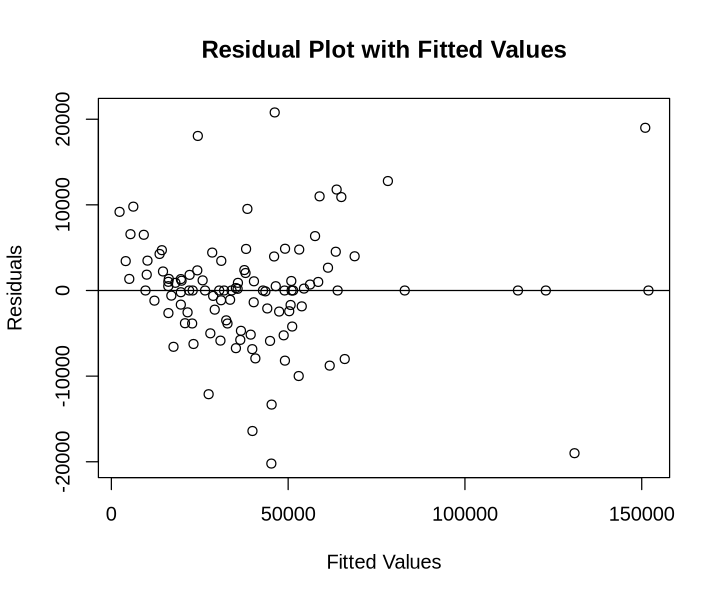

In [10]:
options(repr.plot.width = 6, repr.plot.height = 5)
plot(fitted(benzFit1), resid(benzFit1), main = "Residual Plot with Fitted Values", xlab = "Fitted Values", ylab = "Residuals") # plot fitted values and residuals
abline(0,0)                                                                         # add horizontal line at 0 


In [15]:
benzFit2 <- lm(Price_USD ~ . -Trim_Level, data = benzData)

summary(benzFit2)


Call:
lm(formula = Price_USD ~ . - Trim_Level, data = benzData)

Residuals:
   Min     1Q Median     3Q    Max 
-41599 -11875  -3394   6761  90911 

Coefficients:
                              Estimate Std. Error t value Pr(>|t|)    
(Intercept)                 58340.6328 13259.2798   4.400 2.76e-05 ***
Vehicle_Age                 -1676.7767   960.8614  -1.745  0.08411 .  
Body_TypeElectric SUV/Sedan  5578.7660 16391.2555   0.340  0.73432    
Body_TypeOther              32245.7940 13681.3886   2.357  0.02042 *  
Body_TypeSedan                968.8478 12968.7591   0.075  0.94060    
Body_TypeSports/Roadster    34250.2726 19270.9868   1.777  0.07862 .  
Body_TypeSUV                -3940.1469 12899.2928  -0.305  0.76067    
Body_TypeVan/Commercial       511.4602 15318.2607   0.033  0.97343    
Is_4MATIC                    4108.8984  5356.1065   0.767  0.44484    
Mileage_Miles                  -0.3138     0.1051  -2.986  0.00357 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.

In [16]:
vifBenzFit2 <- vif(benzFit2)

vifBenzFit2

,GVIF,Df,GVIF^(1/(2*Df))
Vehicle_Age,3.308018,1,1.818796
Body_Type,1.553849,6,1.037411
Is_4MATIC,1.536309,1,1.239479
Mileage_Miles,3.109174,1,1.763285


In [11]:
rmarkdown::convert_ipynb("ProjectReportDraft1.ipynb")

In [12]:
knitr::purl("ProjectReportDraft1.Rmd")



processing file: ProjectReportDraft1.Rmd



1/25                   
2/25 [unnamed-chunk-1] 
3/25                   
4/25 [unnamed-chunk-2] 
5/25                   
6/25 [unnamed-chunk-3] 
7/25                   
8/25 [unnamed-chunk-4] 
9/25                   
10/25 [unnamed-chunk-5] 
11/25                   
12/25 [unnamed-chunk-6] 
13/25                   
14/25 [unnamed-chunk-7] 
15/25                   
16/25 [unnamed-chunk-8] 
17/25                   
18/25 [unnamed-chunk-9] 
19/25                   
20/25 [unnamed-chunk-10]
21/25                   
22/25 [unnamed-chunk-11]
23/25                   
24/25 [unnamed-chunk-12]
25/25                   


output file: ProjectReportDraft1.R




[1] "ProjectReportDraft1.R"